In [2]:
# Core
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay


In [3]:
SEED = 0

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Seed set to:", SEED)


Seed set to: 0


In [4]:
with open("training dataset/tabular/engineered_feature_groups.json") as f:
    feature_groups = json.load(f)

phase1_features = (
    feature_groups["Clinical"] +
    feature_groups["Laboratory"] +
    feature_groups["Demographic / Other"] +
    feature_groups["Scoring"] +
    feature_groups["clinical_derived"] +
    feature_groups["lab_derived"]
)

print("Phase 1 feature count:", len(phase1_features))


Phase 1 feature count: 50


In [5]:
train_df = pd.read_csv("training dataset/tabular/train_split.csv")
val_df   = pd.read_csv("training dataset/tabular/val_split.csv")
test_df  = pd.read_csv("training dataset/tabular/test_split.csv")

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)


Train: (546, 103)
Val: (78, 103)
Test: (157, 103)


In [6]:
available_features = [f for f in phase1_features if f in train_df.columns]
print("Final features used:", len(available_features))


Final features used: 50


In [7]:
TARGET = "Diagnosis"

X_train = train_df[available_features]
y_train = train_df[TARGET]

X_val = val_df[available_features]
y_val = val_df[TARGET]

X_test = test_df[available_features]
y_test = test_df[TARGET]

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (546, 50)
Val shape: (78, 50)
Test shape: (157, 50)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Scaled train:", X_train_scaled.shape)
print("Scaled val:", X_val_scaled.shape)
print("Scaled test:", X_test_scaled.shape)


Scaled train: (546, 50)
Scaled val: (78, 50)
Scaled test: (157, 50)


In [9]:
small_mlp = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(16, activation="relu", name="clinical_embedding"),
    Dense(1, activation="sigmoid")
])

small_mlp.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

small_mlp.summary()


C:\Users\Trinabh Mitra\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clinical_embedding (Dense)      │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,177 (8.50 KB)

 Trainable params: 2,177 (8.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(
    monitor="val_auc",
    patience=10,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

history = small_mlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3919 - auc: 0.3929 - loss: 0.9830 - val_accuracy: 0.5256 - val_auc: 0.5156 - val_loss: 0.7606
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5055 - auc: 0.5299 - loss: 0.7258 - val_accuracy: 0.6282 - val_auc: 0.6814 - val_loss: 0.6470
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6209 - auc: 0.6666 - loss: 0.6426 - val_accuracy: 0.6410 - val_auc: 0.7089 - val_loss: 0.6062
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6923 - auc: 0.7489 - loss: 0.5864 - val_accuracy: 0.6410 - val_auc: 0.7201 - val_loss: 0.5899
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7216 - auc: 0.7891 - loss: 0.5478 - val_accuracy: 0.6538 - val_auc: 0.7364 - val_loss: 0.5815
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7381 - auc: 0.8040 - loss: 0.5253 - val_accuracy: 0.6795 - val_auc: 0.7449 - val_loss: 0.5740
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms

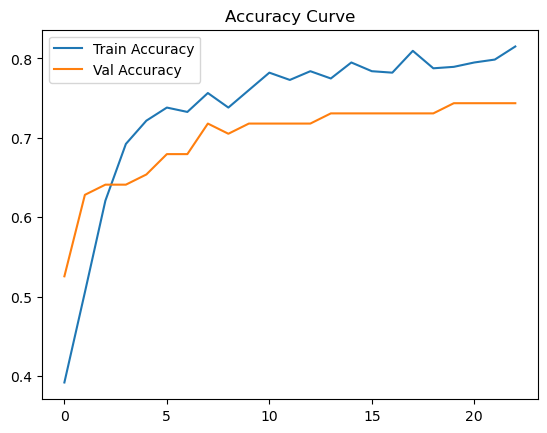

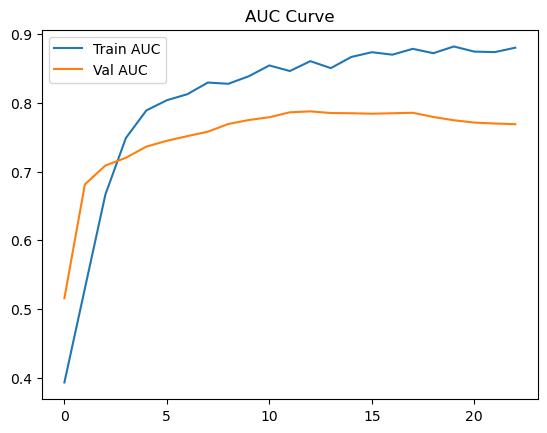

In [11]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Val AUC")
plt.legend()
plt.title("AUC Curve")
plt.show()


In [19]:
val_probs = small_mlp.predict(X_val_scaled).ravel()

thresholds = np.arange(0.6, 0.65, 0.001)
results = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    acc = accuracy_score(y_val, preds)
    auc = roc_auc_score(y_val, val_probs)
    results.append((t, acc, auc))

results_df = pd.DataFrame(results, columns=["threshold", "accuracy", "auc"])
results_df.sort_values("accuracy", ascending=False)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


,threshold,accuracy,auc
14,0.614,0.756410,0.788043
17,0.617,0.756410,0.788043
15,0.615,0.756410,0.788043
18,0.618,0.756410,0.788043
13,0.613,0.756410,0.788043
12,0.612,0.756410,0.788043
11,0.611,0.756410,0.788043
16,0.616,0.756410,0.788043
37,0.637,0.743590,0.788043
39,0.639,0.743590,0.788043


*Seed 0 and threshold 0.614* give the best initial performance

In [21]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 0

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed set to:", SEED)


Seed set to: 0


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.feature_selection import SelectKBest, f_classif


In [24]:
SELECT_K = 30

selector = SelectKBest(score_func=f_classif, k=SELECT_K)

X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_val_sel   = selector.transform(X_val_scaled)

print("Selected features:", SELECT_K)
print("Train shape:", X_train_sel.shape)
print("Val shape:", X_val_sel.shape)


Selected features: 30
Train shape: (546, 30)
Val shape: (78, 30)


In [25]:
model = Sequential([
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.001),
          input_shape=(X_train_sel.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(16, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()


C:\Users\Trinabh Mitra\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,729 (6.75 KB)

 Trainable params: 1,633 (6.38 KB)

 Non-trainable params: 96 (384.00 B)

In [26]:
early_stop = EarlyStopping(
    monitor="val_auc",
    patience=10,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

history = model.fit(
    X_train_sel, y_train,
    validation_data=(X_val_sel, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5769 - auc: 0.5722 - loss: 0.8501 - val_accuracy: 0.5128 - val_auc: 0.6620 - val_loss: 0.7858
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6685 - auc: 0.7095 - loss: 0.6984 - val_accuracy: 0.6667 - val_auc: 0.7330 - val_loss: 0.7077
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7088 - auc: 0.7733 - loss: 0.6283 - val_accuracy: 0.7051 - val_auc: 0.7497 - val_loss: 0.6740
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7051 - auc: 0.7742 - loss: 0.6233 - val_accuracy: 0.7051 - val_auc: 0.7548 - val_loss: 0.6590
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7289 - auc: 0.7978 - loss: 0.5983 - val_accuracy: 0.7436 - val_auc: 0.7599 - val_loss: 0.6495
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7271 - auc: 0.8059 - loss: 0.5834 - val_accuracy: 0.7564 - val_auc: 0.7551 - val_loss: 0.6447
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms

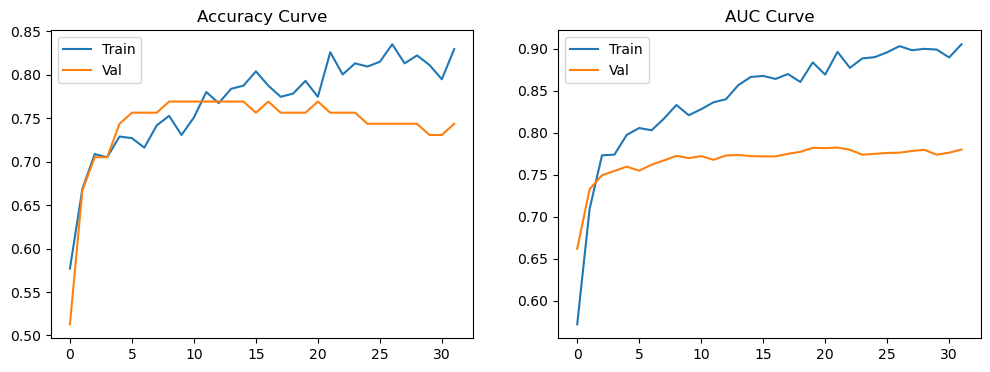

In [27]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy Curve")
plt.legend()

# AUC
plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train')
plt.plot(history.history['val_auc'], label='Val')
plt.title("AUC Curve")
plt.legend()

plt.show()


In [28]:
THRESHOLD = 0.614

val_probs = model.predict(X_val_sel).ravel()
val_preds = (val_probs >= THRESHOLD).astype(int)

val_accuracy = accuracy_score(y_val, val_preds)
val_auc = roc_auc_score(y_val, val_probs)

print(f"Threshold: {THRESHOLD}")
print(f"Validation Accuracy: {val_accuracy:.3f}")
print(f"Validation AUC: {val_auc:.3f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Threshold: 0.614
Validation Accuracy: 0.744
Validation AUC: 0.784


In [29]:
thresholds = np.arange(0.5, 0.7, 0.005)
results = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    acc = accuracy_score(y_val, preds)
    results.append((t, acc))

best_t, best_acc = max(results, key=lambda x: x[1])

print("Best threshold:", best_t)
print("Best accuracy:", best_acc)


Best threshold: 0.51
Best accuracy: 0.7692307692307693


In [30]:
X_test_sel = selector.transform(X_test_scaled)  # if using feature selection
# otherwise: X_test_sel = X_test_scaled

test_probs = model.predict(X_test_sel).ravel()
test_preds = (test_probs >= THRESHOLD).astype(int)

test_accuracy = accuracy_score(y_test, test_preds)
test_auc = roc_auc_score(y_test, test_probs)

print("Test Accuracy:", round(test_accuracy, 3))
print("Test AUC:", round(test_auc, 3))


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Test Accuracy: 0.682
Test AUC: 0.756


In [31]:
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)
class_distribution = dict(zip(unique, counts))
class_distribution


{np.int64(0): np.int64(221), np.int64(1): np.int64(325)}

In [32]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
print(class_weights)


{np.int64(0): np.float64(1.2352941176470589), np.int64(1): np.float64(0.84)}


In [34]:
history = small_mlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7619 - auc: 0.8545 - loss: 0.4744 - val_accuracy: 0.7179 - val_auc: 0.7904 - val_loss: 0.5544
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7985 - auc: 0.8701 - loss: 0.4482 - val_accuracy: 0.7436 - val_auc: 0.7908 - val_loss: 0.5590
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7857 - auc: 0.8728 - loss: 0.4422 - val_accuracy: 0.7436 - val_auc: 0.7891 - val_loss: 0.5652
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7857 - auc: 0.8651 - loss: 0.4542 - val_accuracy: 0.7308 - val_auc: 0.7799 - val_loss: 0.5687
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7875 - auc: 0.8702 - loss: 0.4463 - val_accuracy: 0.7308 - val_auc: 0.7816 - val_loss: 0.5746
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7967 - auc: 0.8761 - loss: 0.4361 - val_accuracy: 0.7308 - val_auc: 0.7745 - val_loss: 0.5838
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

In [35]:
from sklearn.metrics import classification_report

y_val_pred = (small_mlp.predict(X_val_scaled) > 0.614).astype(int)

print(classification_report(y_val, y_val_pred))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
              precision    recall  f1-score   support

           0       0.63      0.75      0.69        32
           1       0.80      0.70      0.74        46

    accuracy                           0.72        78
   macro avg       0.72      0.72      0.71        78
weighted avg       0.73      0.72      0.72        78



In [36]:
# Create embedding extractor model
embedding_model = tf.keras.Model(
    inputs=small_mlp.input,
    outputs=small_mlp.get_layer("clinical_embedding").output
)

# Generate embeddings
train_embeddings = embedding_model.predict(X_train_scaled)
val_embeddings = embedding_model.predict(X_val_scaled)
test_embeddings = embedding_model.predict(X_test_scaled)

print("Train embeddings shape:", train_embeddings.shape)
print("Val embeddings shape:", val_embeddings.shape)
print("Test embeddings shape:", test_embeddings.shape)


AttributeError: The layer sequential has never been called and thus has no defined input.